#### Fase 3 — Camada Gold: Análise de Viagens a Serviço
Pipeline: Raw → Silver → **Gold**. Este notebook responde 7 perguntas de negócio com SQL, tabelas e gráficos.

> **Nota sobre a organização deste notebook:** as 7 perguntas de negócio estão agrupadas por **fonte de dados**, não pela ordem numérica do enunciado. Primeiro respondi as perguntas que dependem de uma única tabela Silver (**Bloco A** — perguntas 3, 4 e 5). Em seguida, construí a **camada Gold** (`gold_orgao` e `gold_destino`), agregando dados via `JOIN` + `GROUP BY`. Por fim, respondemos as perguntas que dependem dessas agregações (**Bloco C** — perguntas 1, 2, 6 e 7), consultando diretamente a Gold em vez de repetir os `JOIN`s a cada pergunta. Todas as 7 perguntas são respondidas — apenas a ordem de apresentação segue a lógica de construção do pipeline (Silver → Gold), não a ordem do enunciado.


In [1]:
import sys
from pathlib import Path

In [2]:
# Descobre a raiz do projeto: sobe pastas ate achar o config.py.
pasta = Path.cwd()
while not (pasta / "config.py").exists() and pasta != pasta.parent:
    pasta = pasta.parent
sys.path.insert(0, str(pasta))

import pandas as pd
import matplotlib.pyplot as plt 
from database.banco import conectar, executar 

def consultar(sql):
    """Executa um SELECT e devolve o resultado como DataFrame do pandas."""
    con = conectar()
    cur = con.cursor()
    cur.execute(sql)
    colunas = [descricao[0] for descricao in cur.description]
    dados = cur.fetchall()
    cur.close()
    con.close()
    return pd.DataFrame(dados, columns=colunas)

    # Teste rapido: quantas viagens temos na silver?
consultar("SELECT count(*) AS total_viagens FROM silver_viagem")

,total_viagens
0,341860


#### Pergunta 3 — Qual a viagem de maior duração e seu custo total?

Resposta: A viagem de maior duração foi a de LUISANGELA CORREA FRANCO DE FARIA (Ministério da Previdência Social), com 383 dias (13/01/2025 a 31/01/2026), porém com custo total de R$ 0,00.

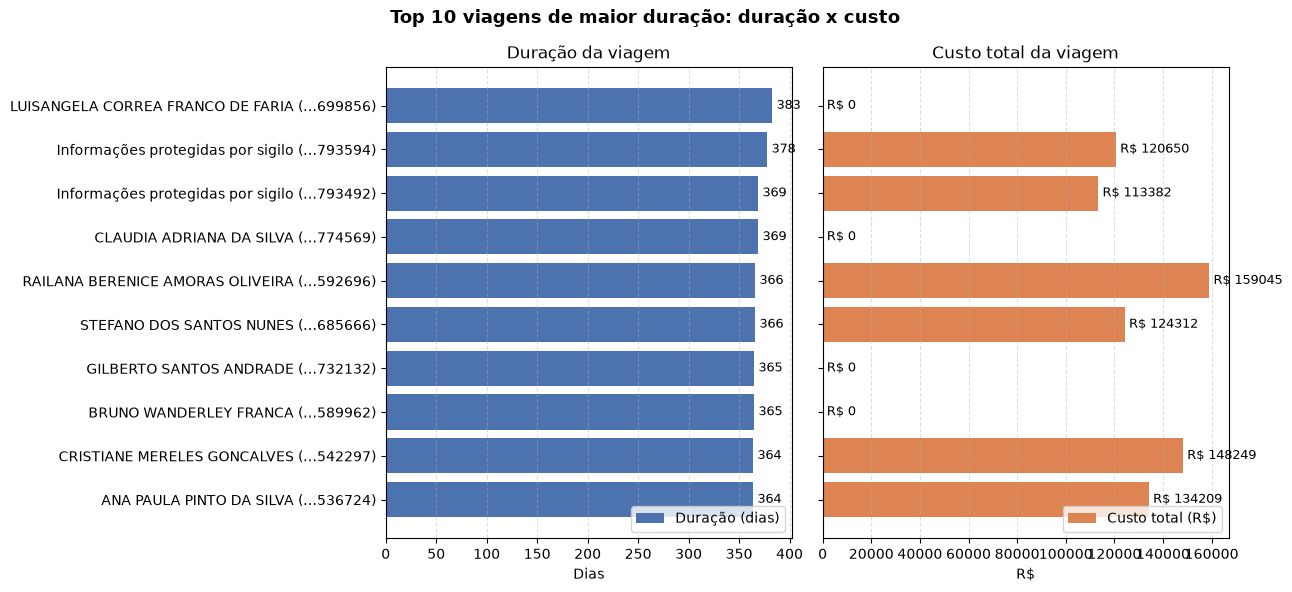

Isso não é erro de tratamento dos dados — o próprio dado bruto do Portal da Transparência já traz zerado (0,00) em todos os campos de valor dessa viagem. A viagem possui trechos registrados, mas nenhum pagamento lançado neste recorte de 6 meses — provavelmente por estar em andamento ou aguardar processamento financeiro. Esse padrão não é isolado: 18.553 viagens (5,4% do total) têm valor_total = 0.

Entre as viagens de maior duração com custo efetivamente registrado, destaca-se a de 378 dias (Ministério da Justiça e Segurança Pública), com custo total de R$ 120.650,00

In [3]:
df_p3 = consultar("""
    SELECT id_viagem, nome_viajante, nome_orgao_superior, destinos,
            duracao_dias, valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 10
""")
df_p3

,id_viagem,nome_viajante,nome_orgao_superior,destinos,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,Mogi Mirim/SP,383,0.00
1,0000000000020793594,Informações protegidas por sigilo,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,378,120650.00
2,0000000000020793492,Informações protegidas por sigilo,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,369,113382.50
3,0000000000020774569,CLAUDIA ADRIANA DA SILVA,Ministério da Educação,Bariloche/Argentina,369,0.00
4,0000000000020592696,RAILANA BERENICE AMORAS OLIVEIRA,Ministério da Justiça e Segurança Pública,"Brasília/DF, Belo Horizonte/MG, Brasília/DF, F...",366,159044.90
5,0000000000020685666,STEFANO DOS SANTOS NUNES,Ministério da Justiça e Segurança Pública,"Brasília/DF, Brasília/DF, Rio de Janeiro/RJ, B...",366,124312.50
6,0000000000020732132,GILBERTO SANTOS ANDRADE,Ministério da Educação,Angers/França,365,0.00
7,0000000000020589962,BRUNO WANDERLEY FRANCA,Ministério da Educação,Aberdeen/Reino Unido,365,0.00
8,0000000000020542297,CRISTIANE MERELES GONCALVES,Ministério da Justiça e Segurança Pública,"Brasília/DF, João Pessoa/PB, Brasília/DF, Reci...",364,148248.73
9,0000000000020536724,ANA PAULA PINTO DA SILVA,Ministério da Justiça e Segurança Pública,"Brasília/DF, Belém/PA, Brasília/DF, Brasília/D...",364,134208.77


In [4]:
df_p3.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id_viagem            10 non-null     str   
 1   nome_viajante        10 non-null     str   
 2   nome_orgao_superior  10 non-null     str   
 3   destinos             10 non-null     str   
 4   duracao_dias         10 non-null     int64 
 5   valor_total          10 non-null     object
dtypes: int64(1), object(1), str(4)
memory usage: 612.0+ bytes


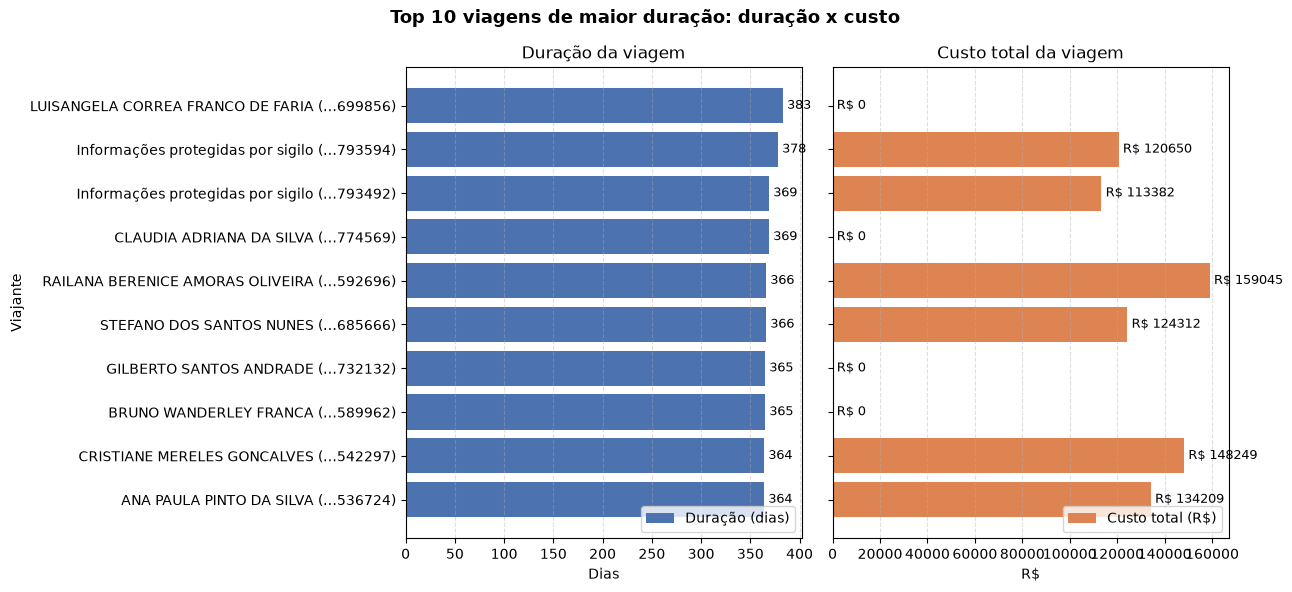

In [5]:
# Rotulo do eixo Y: nome do viajante + inicio dos ultimos digitos do id
# (para distinguir viajantes com nome sigiloso repetido)
rotulos = df_p3["nome_viajante"] + " (…" + df_p3["id_viagem"].str[-6:] + ")"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

barras1 = ax1.barh(rotulos, df_p3["duracao_dias"], color="#4C72B0", label="Duração (dias)")
ax1.invert_yaxis()
ax1.set_title("Duração da viagem")
ax1.set_xlabel("Dias")
ax1.set_ylabel("Viajante")
ax1.bar_label(barras1, padding=3, fontsize=9)
ax1.legend(loc="lower right")
ax1.grid(axis="x", linestyle="--", alpha=0.4)

barras2 = ax2.barh(rotulos, df_p3["valor_total"], color="#DD8452", label="Custo total (R$)")
ax2.set_title("Custo total da viagem")
ax2.set_xlabel("R$")
ax2.bar_label(barras2, padding=3, fontsize=9, fmt="R$ %.0f")
ax2.legend(loc="lower right")
ax2.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle("Top 10 viagens de maior duração: duração x custo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


#### Pergunta 4 — Qual o tipo de pagamento com maior valor médio?

Resposta: O tipo de pagamento com maior valor médio é DIÁRIAS, com média de R$ 2.078,28 por pagamento (401.463 pagamentos, somando R$ 834,4 milhões no total).

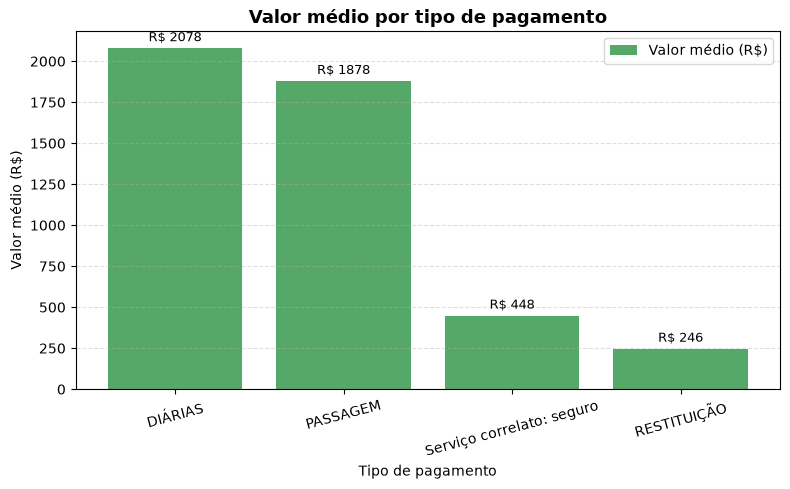

Logo atrás vem PASSAGEM, com média de R$ 1.878,34 (188.985 pagamentos, R$ 355 milhões no total) — uma diferença pequena entre os dois principais tipos. Já "Serviço correlato: seguro" (R$ 447,51) e RESTITUIÇÃO (R$ 245,70) têm valores médios bem menores, condizentes com sua natureza de custos acessórios/pontuais, e não com o deslocamento em si.

In [6]:
df_p4 = consultar("""
    SELECT tipo_pagamento,
           count(*) AS num_pagamentos,
           round(avg(valor), 2) AS valor_medio,
           round(sum(valor), 2) AS valor_total
    FROM silver_pagamento
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
""")
df_p4

,tipo_pagamento,num_pagamentos,valor_medio,valor_total
0,DIÁRIAS,401463,2078.28,834352643.52
1,PASSAGEM,188985,1878.34,354978915.13
2,Serviço correlato: seguro,4894,447.51,2190136.71
3,RESTITUIÇÃO,11574,245.70,2843762.01


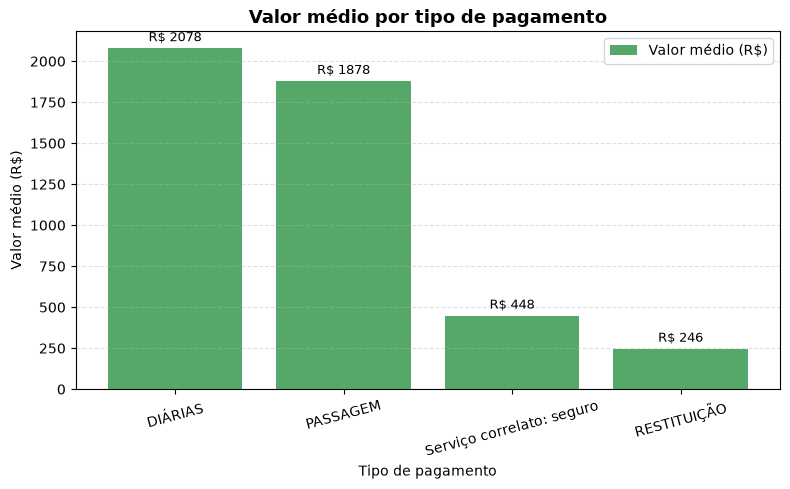

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(df_p4["tipo_pagamento"], df_p4["valor_medio"],
                 color="#55A868", label="Valor médio (R$)")

ax.set_title("Valor médio por tipo de pagamento", fontsize=13, fontweight="bold")
ax.set_xlabel("Tipo de pagamento")
ax.set_ylabel("Valor médio (R$)")
ax.bar_label(barras, padding=3, fontsize=9, fmt="R$ %.0f")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


#### Pergunta 5 — Qual o meio de transporte mais usado nos trechos?

Resposta: O meio de transporte mais usado nos trechos é Veículo Oficial, presente em 386.424 trechos (50,6% do total) — ou seja, mais da metade de todos os deslocamentos. Em segundo lugar vem o transporte Aéreo, com 232.666 trechos (30,5%), seguido por Rodoviário (8,5%) e Veículo Próprio (5,6%).

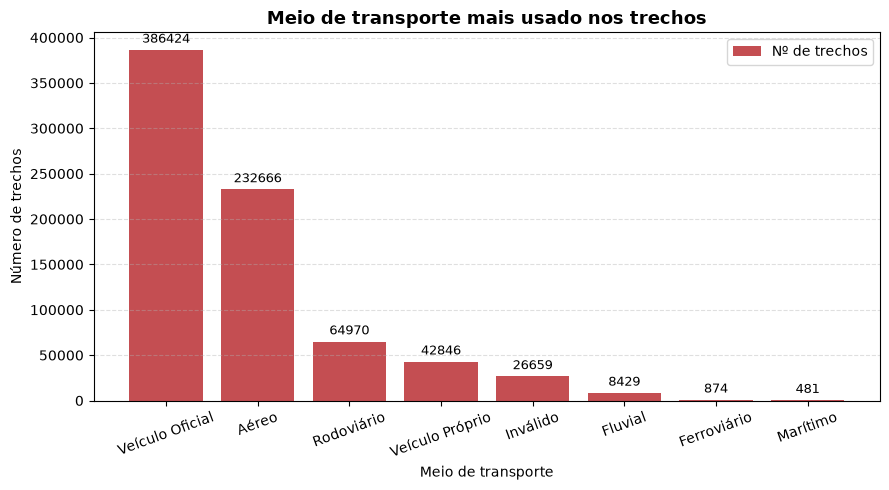

Vale notar que 3,5% dos trechos (26.659) estão registrados com o valor "Inválido" — uma inconsistência já presente no dado bruto do Portal da Transparência, não introduzida pelo pipeline. Os meios menos usados são Fluvial (1,1%), Ferroviário e Marítimo (0,1% cada).

In [8]:
df_p5 = consultar("""
    SELECT meio_transporte, count(*) AS num_trechos
    FROM silver_trecho
    GROUP BY meio_transporte
    ORDER BY num_trechos DESC
""")
df_p5


,meio_transporte,num_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


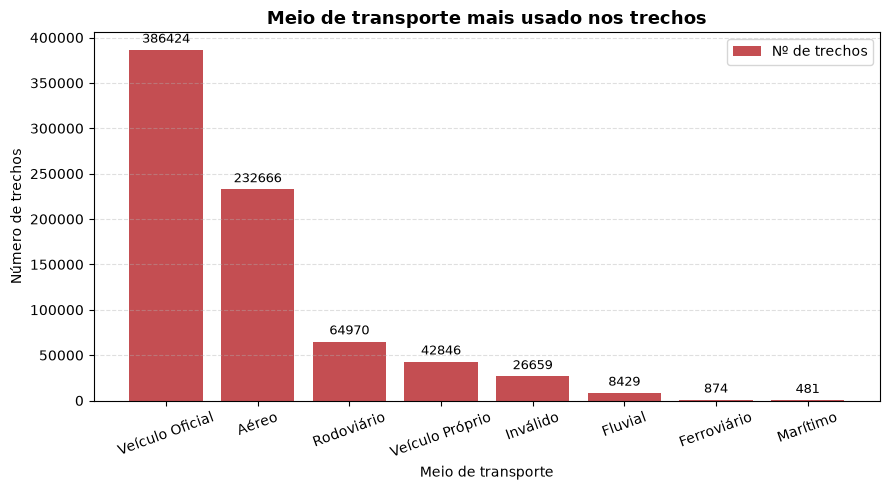

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(df_p5["meio_transporte"], df_p5["num_trechos"], color="#C44E52",
                 label="Nº de trechos")

ax.set_title("Meio de transporte mais usado nos trechos", fontsize=13, fontweight="bold")
ax.set_xlabel("Meio de transporte")
ax.set_ylabel("Número de trechos")
ax.bar_label(barras, padding=3, fontsize=9, fmt="%.0f")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### Camada Gold — `gold_orgao`

Agrega viagens e pagamentos por órgão superior. Usa uma subconsulta que soma os pagamentos **por viagem primeiro** (evitando duplicar `valor_total` quando uma viagem tem múltiplos pagamentos).

In [10]:
con = conectar()
executar(con, "DROP TABLE IF EXISTS gold_orgao CASCADE;")
executar(con, """
    CREATE TABLE gold_orgao AS
    WITH pagamentos_por_viagem AS (
        SELECT id_viagem, SUM(valor) AS total_pago_viagem
        FROM silver_pagamento
        GROUP BY id_viagem
    )
    SELECT
        v.nome_orgao_superior AS orgao,
        COUNT(*) AS num_viagens,
        SUM(v.valor_total) AS custo_total,
        ROUND(AVG(v.valor_total), 2) AS custo_medio,
        SUM(COALESCE(p.total_pago_viagem, 0)) AS total_pago
    FROM silver_viagem v
    LEFT JOIN pagamentos_por_viagem p ON p.id_viagem = v.id_viagem
    GROUP BY v.nome_orgao_superior
""")

executar(con, "DROP VIEW IF EXISTS vw_gold_orgao;")
executar(con, "CREATE VIEW vw_gold_orgao AS SELECT * FROM gold_orgao;")
con.close()

consultar("SELECT * FROM gold_orgao ORDER BY custo_total DESC LIMIT 5")


,orgao,num_viagens,custo_total,custo_medio,total_pago
0,Ministério da Justiça e Segurança Pública,75742,486933121.65,6428.84,488831110.61
1,Ministério da Defesa,61912,156070304.49,2520.84,156549767.91
2,Ministério da Educação,65295,111291349.34,1704.44,111897434.35
3,Ministério do Meio Ambiente e Mudança do Clima,19413,49697710.16,2560.02,50123043.80
4,Ministério da Previdência Social,8190,40417309.06,4934.96,40659494.63


#### Camada Gold — `gold_destino`

Agrega trechos e viagens por UF de destino. `num_trechos` conta trechos normalmente; `custo_medio_viagem` usa pares (viagem, UF) **distintos**, para não contar a mesma viagem duas vezes quando ela tem múltiplos trechos para a mesma UF.


In [11]:
con = conectar()
executar(con, "DROP TABLE IF EXISTS gold_destino CASCADE;")
executar(con, """
    CREATE TABLE gold_destino AS
    WITH viagens_por_destino AS (
        SELECT DISTINCT id_viagem, destino_uf
        FROM silver_trecho
        WHERE destino_uf IS NOT NULL AND destino_uf <> ''
    ),
    trechos_por_uf AS (
        SELECT destino_uf, COUNT(*) AS num_trechos
        FROM silver_trecho
        WHERE destino_uf IS NOT NULL AND destino_uf <> ''
        GROUP BY destino_uf
    ),
    viagens_por_uf AS (
        SELECT vd.destino_uf,
               COUNT(*) AS num_viagens,
               ROUND(AVG(v.valor_total), 2) AS custo_medio_viagem
        FROM viagens_por_destino vd
        JOIN silver_viagem v ON v.id_viagem = vd.id_viagem
        GROUP BY vd.destino_uf
    )
    SELECT t.destino_uf, t.num_trechos, u.num_viagens, u.custo_medio_viagem
    FROM trechos_por_uf t
    JOIN viagens_por_uf u ON u.destino_uf = t.destino_uf
""")

executar(con, "DROP VIEW IF EXISTS vw_gold_destino;")
executar(con, "CREATE VIEW vw_gold_destino AS SELECT * FROM gold_destino;")
con.close()

consultar("SELECT * FROM gold_destino ORDER BY num_trechos DESC LIMIT 5")


,destino_uf,num_trechos,num_viagens,custo_medio_viagem
0,São Paulo,82722,46392,3320.49
1,Distrito Federal,79962,72297,7281.91
2,Minas Gerais,50965,26891,2450.48
3,Rio de Janeiro,44197,35050,5025.25
4,Paraná,42603,22263,4485.14


#### Pergunta 1 — Quais os 5 órgãos com maior custo total? *(via camada Gold)*

Resposta: Os 5 órgãos com maior custo total em viagens são: Ministério da Justiça e Segurança Pública (R$ 486,9 milhões, 75.742 viagens), Ministério da Defesa (R$ 156,1 milhões), Ministério da Educação (R$ 111,3 milhões), Ministério do Meio Ambiente e Mudança do Clima (R$ 49,7 milhões) e Ministério da Previdência Social (R$ 40,4 milhões). O primeiro colocado gasta mais de 3x o segundo colocado.

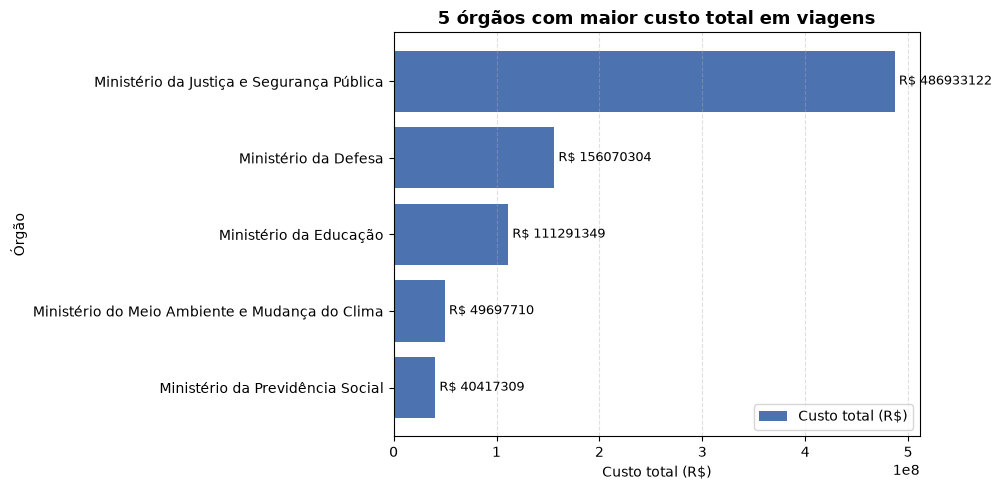


In [12]:
df_p1 = consultar("""
    SELECT orgao, num_viagens, custo_total
    FROM gold_orgao
    ORDER BY custo_total DESC
    LIMIT 5
""")
df_p1

,orgao,num_viagens,custo_total
0,Ministério da Justiça e Segurança Pública,75742,486933121.65
1,Ministério da Defesa,61912,156070304.49
2,Ministério da Educação,65295,111291349.34
3,Ministério do Meio Ambiente e Mudança do Clima,19413,49697710.16
4,Ministério da Previdência Social,8190,40417309.06


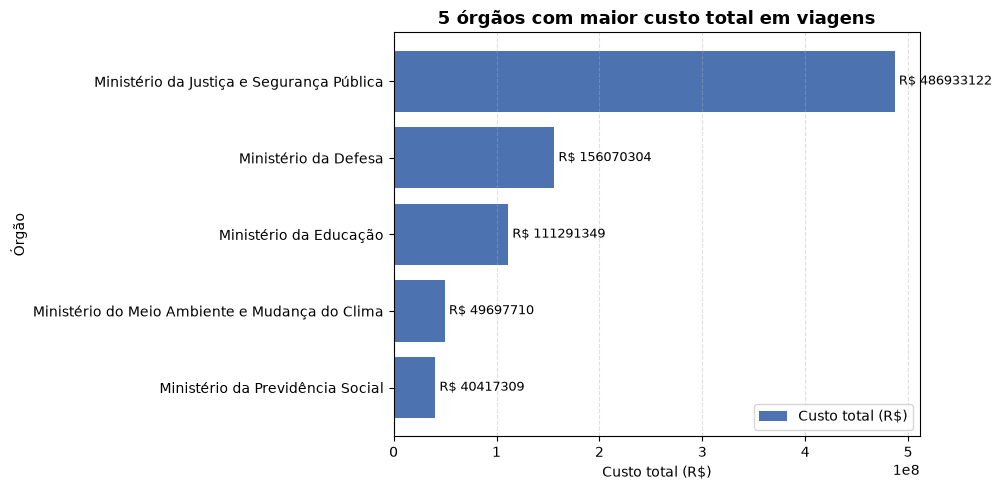

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(df_p1["orgao"], df_p1["custo_total"], color="#4C72B0", label="Custo total (R$)")
ax.invert_yaxis()
ax.set_title("5 órgãos com maior custo total em viagens", fontsize=13, fontweight="bold")
ax.set_xlabel("Custo total (R$)")
ax.set_ylabel("Órgão")
ax.bar_label(barras, padding=3, fontsize=9, fmt="R$ %.0f")
ax.legend(loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


#### Pergunta 7 — Qual órgão pagou mais no total? *(via camada Gold)*

Resposta: O órgão que mais pagou no total foi o Ministério da Justiça e Segurança Pública, com R$ 488,8 milhões pagos — o mesmo líder da Pergunta 1, o que é coerente: é o órgão com mais viagens (75.742) e maior custo, então naturalmente também é quem mais desembolsa. A pequena diferença entre custo_total (R$ 486,9M, calculado na viagem) e total_pago (R$ 488,8M, somado dos pagamentos reais) é esperada — são métricas de fontes diferentes.

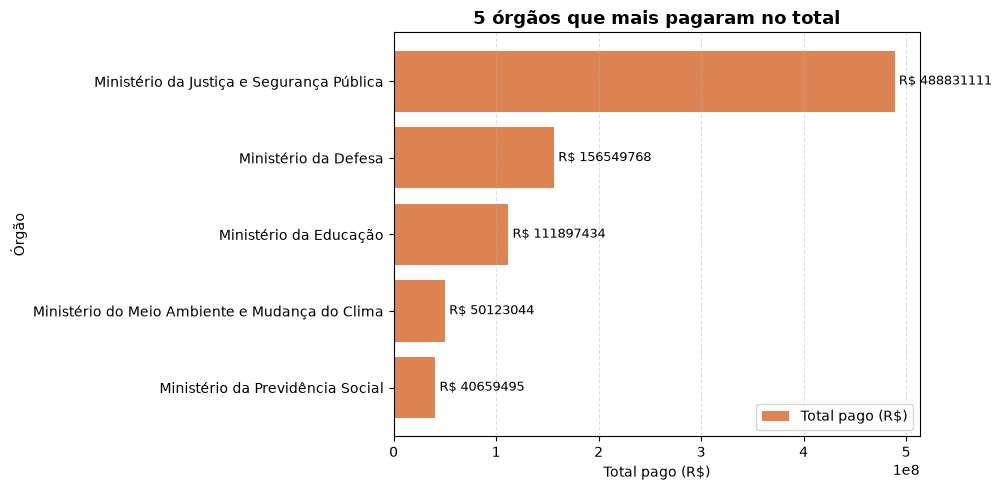

In [14]:
df_p7 = consultar("""
    SELECT orgao, total_pago
    FROM gold_orgao
    ORDER BY total_pago DESC
    LIMIT 5
""")
df_p7


,orgao,total_pago
0,Ministério da Justiça e Segurança Pública,488831110.61
1,Ministério da Defesa,156549767.91
2,Ministério da Educação,111897434.35
3,Ministério do Meio Ambiente e Mudança do Clima,50123043.80
4,Ministério da Previdência Social,40659494.63


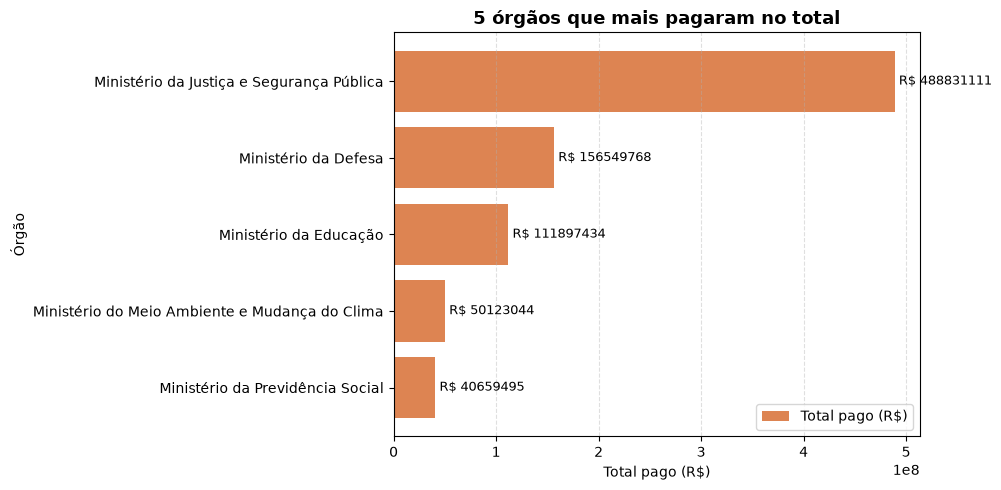

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(df_p7["orgao"], df_p7["total_pago"], color="#DD8452", label="Total pago (R$)")
ax.invert_yaxis()
ax.set_title("5 órgãos que mais pagaram no total", fontsize=13, fontweight="bold")
ax.set_xlabel("Total pago (R$)")
ax.set_ylabel("Órgão")
ax.bar_label(barras, padding=3, fontsize=9, fmt="R$ %.0f")
ax.legend(loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


#### Pergunta 2 — Quais os 3 destinos com maior custo médio por viagem? *(via camada Gold)*
Consideramos "destino" como a UF de destino dos trechos (`destino_uf`), por ser um campo mais limpo e consistente do que o texto livre de `destinos` na viagem.

Resposta: Os 3 destinos com maior custo médio por viagem são Roraima (R$ 11.215,03, 8.850 viagens), Acre (R$ 8.332,78, 5.399 viagens) e Rondônia (R$ 8.193,82, 7.838 viagens) — os três na região Norte, onde a distância e a menor oferta de voos elevam o custo das passagens.

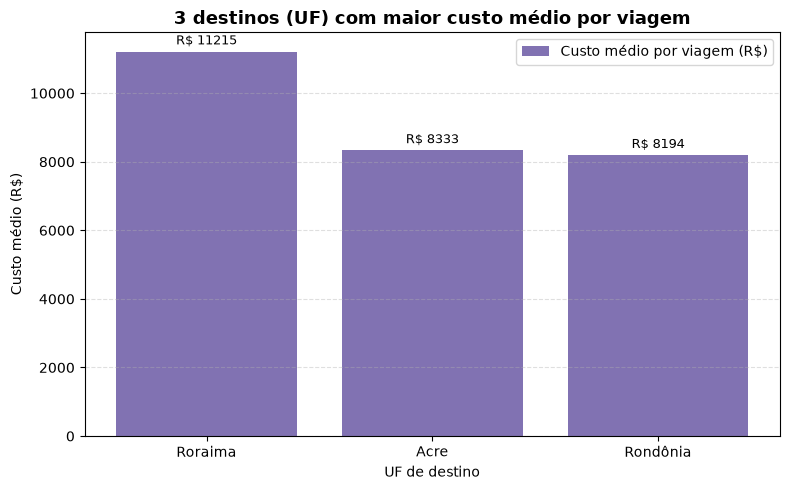

(Nota: um valor de UF "Inválido" aparece logo em seguida, na 4ª posição, com apenas 28 viagens — provável inconsistência do dado original, sem relevância estatística.)

In [16]:
df_p2 = consultar("""
    SELECT destino_uf, num_viagens, custo_medio_viagem
    FROM gold_destino
    ORDER BY custo_medio_viagem DESC
    LIMIT 3
""")
df_p2

,destino_uf,num_viagens,custo_medio_viagem
0,Roraima,8850,11215.03
1,Acre,5399,8332.78
2,Rondônia,7838,8193.82


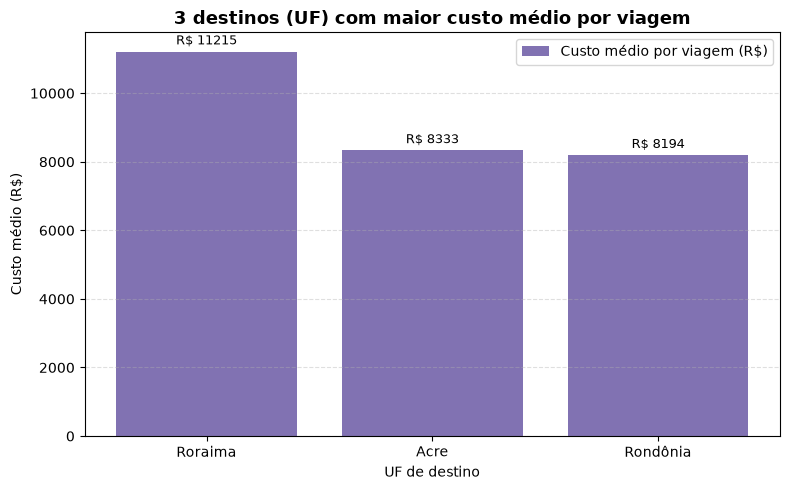

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(df_p2["destino_uf"], df_p2["custo_medio_viagem"], color="#8172B2",
                 label="Custo médio por viagem (R$)")
ax.set_title("3 destinos (UF) com maior custo médio por viagem", fontsize=13, fontweight="bold")
ax.set_xlabel("UF de destino")
ax.set_ylabel("Custo médio (R$)")
ax.bar_label(barras, padding=3, fontsize=9, fmt="R$ %.0f")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### Pergunta 6 — Qual UF de destino aparece em mais trechos? *(via camada Gold)*

Resposta: A UF de destino que aparece em mais trechos é São Paulo, com 82.722 trechos, seguida de perto pelo Distrito Federal (79.962 trechos) — natural, já que concentra os órgãos federais — e Minas Gerais (50.965 trechos).

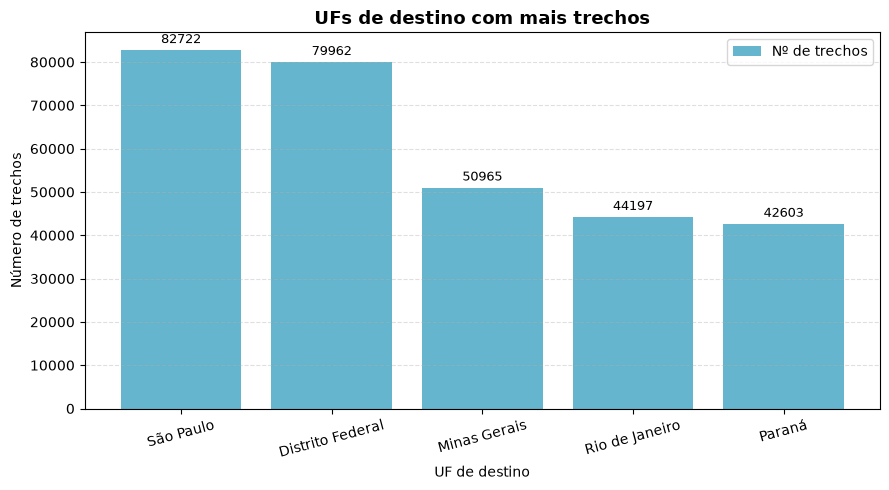


In [18]:
df_p6 = consultar("""
    SELECT destino_uf, num_trechos
    FROM gold_destino
    ORDER BY num_trechos DESC
    LIMIT 5
""")
df_p6

,destino_uf,num_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603


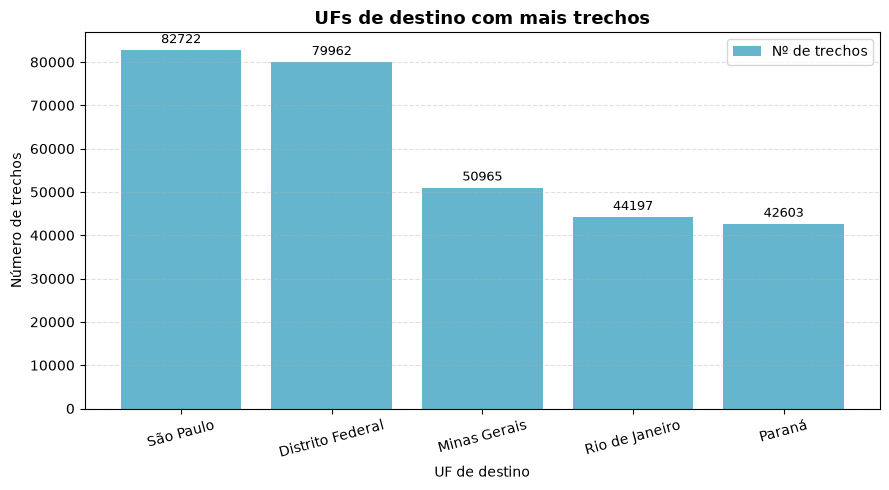

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(df_p6["destino_uf"], df_p6["num_trechos"], color="#64B5CD",
                 label="Nº de trechos")
ax.set_title("UFs de destino com mais trechos", fontsize=13, fontweight="bold")
ax.set_xlabel("UF de destino")
ax.set_ylabel("Número de trechos")
ax.bar_label(barras, padding=3, fontsize=9, fmt="%.0f")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Conclusões e Insights

**Sobre custos e órgãos (P1, P7):** o **Ministério da Justiça e Segurança Pública** lidera com folga tanto em custo total de viagens (R$ 486,9 milhões) quanto em valor pago (R$ 488,8 milhões) — mais de 3x o segundo colocado (Ministério da Defesa). A proximidade entre `custo_total` (calculado na viagem) e `total_pago` (somado dos pagamentos reais) valida a consistência entre as camadas Silver e Gold.

**Sobre geografia e custo (P2, P6):** há uma dissociação interessante entre *volume* e *custo médio*. São Paulo e Distrito Federal concentram o maior número de trechos (maior demanda), mas os destinos mais **caros por viagem** são estados do Norte — Roraima, Acre e Rondônia — refletindo menor oferta de voos e maior distância dos grandes centros.

**Sobre transporte e pagamento (P4, P5):** **Veículo Oficial** domina os trechos (50,6%), à frente do transporte Aéreo (30,5%). Já **Diárias** é o tipo de pagamento com maior valor médio (R$ 2.078,28), levemente acima de Passagens (R$ 1.878,34).

**Sobre qualidade do dado:** o pipeline preservou fielmente inconsistências do dado bruto do Portal da Transparência — como **18.553 viagens (5,4%) com custo zero** (viagens registradas mas ainda sem pagamento lançado) e categorias **"Inválido"** tanto em meio de transporte (3,5% dos trechos) quanto em UF de destino. Isso confirma que a camada Raw cumpriu seu papel de auditoria: nada foi "escondido" ou corrigido silenciosamente — as inconsistências ficam visíveis e documentadas na análise, não maquiadas.

**Sobre a arquitetura Gold:** as duas tabelas (`gold_orgao`, `gold_destino`) tiveram que lidar com um problema clássico de agregação — o **fan-out** (multiplicação indevida de valores ao juntar tabelas em relação um-para-muitos). Em ambos os casos, resolvido agregando os dados **antes** de fazer o JOIN final, garantindo que cada viagem contribua uma única vez para as médias e somas.
